In [1]:
import requests
from bs4 import BeautifulSoup
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [62]:
restaurants=[]
rating=[]
cuisine=[]
delivery_time=[]
cost=[]
location=[]
distance=[]
restaurant_id=[]

coords=[
(17.3850,78.4867),(17.4417,78.4483),(17.4948,78.3996),
(17.3616,78.4747),(17.4065,78.4772),(17.4500,78.3800),
(17.4700,78.4200),(17.5000,78.4500),(17.4200,78.5000),
(17.3800,78.4200),(17.3400,78.4800),(17.4600,78.5000),
(17.4800,78.4700),(17.3900,78.5300),(17.3500,78.4300),
(17.4100,78.4100),(17.4500,78.4700),(17.4300,78.4900),
(17.3600,78.4600),(17.4000,78.5200),(17.4400,78.5200),
(17.4700,78.5100),(17.4800,78.4300),(17.4200,78.4600)
]

headers={"User-Agent":"Mozilla/5.0"}

for lat,lng in coords:

    url="https://www.swiggy.com/dapi/restaurants/list/v5"

    params={
        "lat":lat,
        "lng":lng,
        "page_type":"DESKTOP_WEB_LISTING"
    }

    response=requests.get(url,headers=headers,params=params)

    data=response.json()

    cards=data.get("data",{}).get("cards",[])

    for card in cards:

        try:
            res_list=card["card"]["card"]["gridElements"]["infoWithStyle"]["restaurants"]

            for r in res_list:

                info=r["info"]

                restaurants.append(info.get("name"))
                rating.append(info.get("avgRating"))
                cuisine.append(",".join(info.get("cuisines",[])))
                delivery_time.append(info.get("sla",{}).get("deliveryTime"))
                cost.append(info.get("costForTwoMessage"))
                location.append(info.get("areaName"))
                distance.append(info.get("sla",{}).get("lastMileTravel"))
                restaurant_id.append(info.get("id"))

        except:
            continue

In [78]:
df=pd.DataFrame({
"Restaurant":restaurants,
"Rating":rating,
"Cuisine":cuisine,
"Delivery_Time":delivery_time,
"Cost_for_Two":cost,
"Location":location,
"Distance_km":distance,
"Restaurant_ID":restaurant_id
})

print(df.shape)
df.head()

(672, 8)


,Restaurant,Rating,Cuisine,Delivery_Time,Cost_for_Two,Location,Distance_km,Restaurant_ID
0,Pizza Hut,4.5,Pizzas,28,None,Kachiguda,1.6,408177
1,Wow! Momo,4.3,"Momos,Chinese,fastfood,Asian,Beverages",30,None,Himayath Nagar,2.7,360967
2,Barbeque Nation,3.9,"North Indian,Barbecue,Kebabs,Biryani,Street Fo...",42,None,ABIDS,1.6,603116
3,Domino's Pizza,4.6,"Pizzas,Italian,Pastas,Desserts",25,None,Kachiguda,3.0,28768
4,NIC Ice Creams,4.6,"Ice Cream,Desserts",21,None,Narayanguda,1.8,108986


In [112]:
df.to_csv("swiggy_food_delivery_analysis.csv",index=False)

In [79]:
df.drop(columns=["Cost_for_Two"], inplace=True)

In [80]:
df=df.drop_duplicates()

In [ ]:
df["Rating"]=pd.to_numeric(df["Rating"],errors="coerce")
df["Delivery_Time"]=pd.to_numeric(df["Delivery_Time"],errors="coerce")
df["Distance_km"]=pd.to_numeric(df["Distance_km"],errors="coerce")

In [ ]:
df=df.dropna(subset=["Rating","Delivery_Time"])

In [113]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
Index: 553 entries, 0 to 671
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype   
---  ------             --------------  -----   
 0   Restaurant         553 non-null    object  
 1   Rating             553 non-null    float64 
 2   Cuisine            553 non-null    object  
 3   Delivery_Time      553 non-null    int64   
 4   Location           553 non-null    object  
 5   Distance_km        552 non-null    float64 
 6   Restaurant_ID      553 non-null    object  
 7   Delivery_Category  545 non-null    category
dtypes: category(1), float64(2), int64(1), object(4)
memory usage: 35.2+ KB


,Rating,Delivery_Time,Distance_km
count,553.000000,553.000000,552.000000
mean,4.326221,33.712477,3.438225
std,0.264129,8.737443,1.882069
min,3.400000,15.000000,0.100000
25%,4.200000,27.000000,2.000000
50%,4.300000,33.000000,3.000000
75%,4.500000,36.000000,4.800000
max,4.800000,71.000000,10.500000


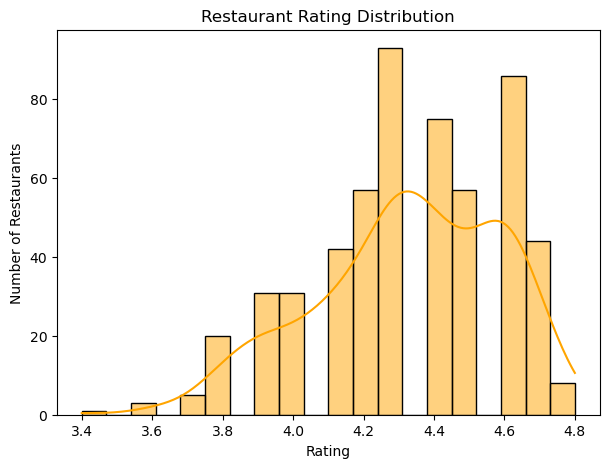

In [82]:
plt.figure(figsize=(7,5))
sns.histplot(df["Rating"],bins=20,color="orange",kde=True)

plt.title("Restaurant Rating Distribution")
plt.xlabel("Rating")
plt.ylabel("Number of Restaurants")

plt.show()

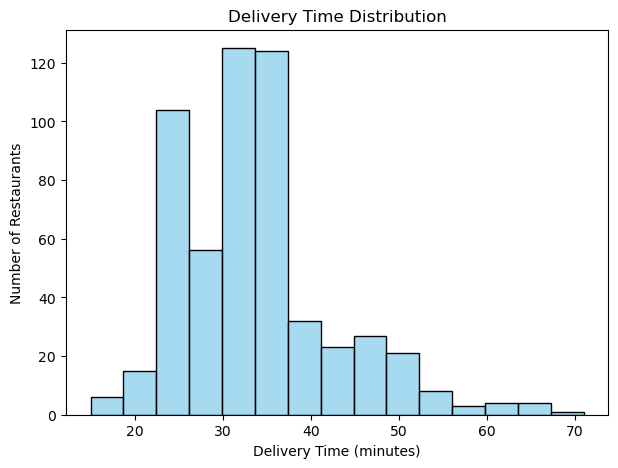

In [83]:
plt.figure(figsize=(7,5))
sns.histplot(df["Delivery_Time"],bins=15,color="skyblue")

plt.title("Delivery Time Distribution")
plt.xlabel("Delivery Time (minutes)")
plt.ylabel("Number of Restaurants")

plt.show()

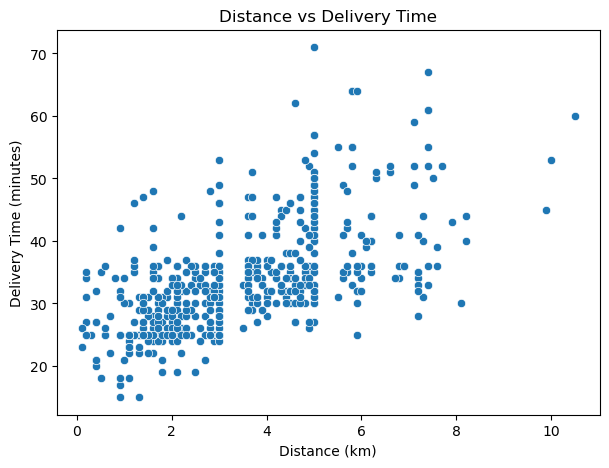

In [84]:
plt.figure(figsize=(7,5))
sns.scatterplot(x="Distance_km",y="Delivery_Time",data=df)

plt.title("Distance vs Delivery Time")
plt.xlabel("Distance (km)")
plt.ylabel("Delivery Time (minutes)")

plt.show()

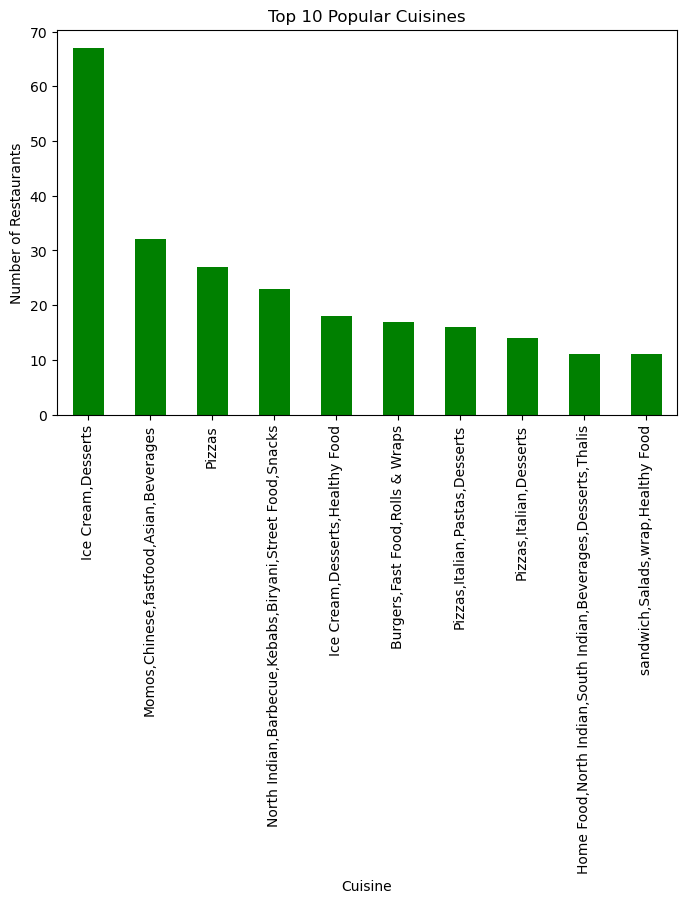

In [73]:
plt.figure(figsize=(8,5))

df["Cuisine"].value_counts().head(10).plot(kind="bar",color="green")

plt.title("Top 10 Popular Cuisines")
plt.xlabel("Cuisine")
plt.ylabel("Number of Restaurants")

plt.show()

C:\Users\megha\AppData\Local\Temp\ipykernel_6644\3189204996.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(y=top_locations.index, x=top_locations.values, palette="coolwarm")


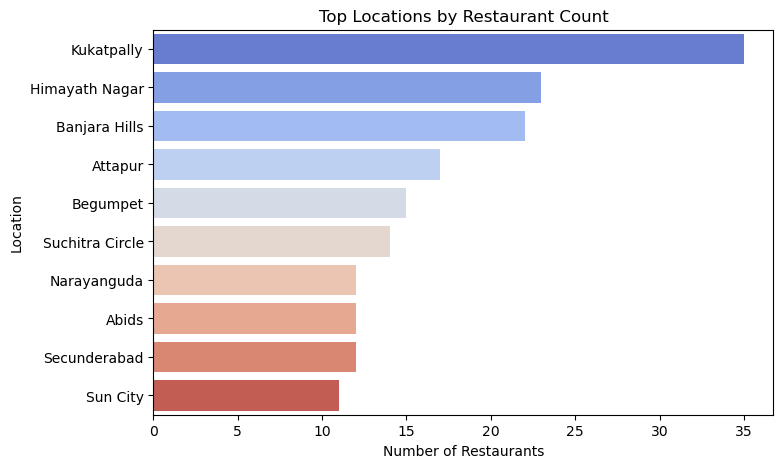

In [88]:
top_locations = df["Location"].value_counts().head(10)

plt.figure(figsize=(8,5))

sns.barplot(y=top_locations.index, x=top_locations.values, palette="coolwarm")

plt.title("Top Locations by Restaurant Count")
plt.xlabel("Number of Restaurants")
plt.ylabel("Location")

plt.show()

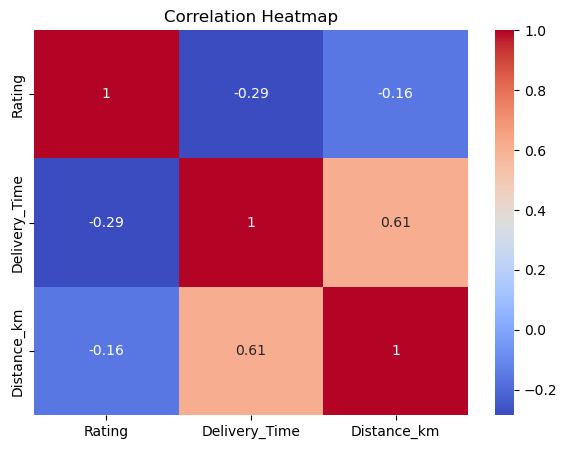

In [87]:
plt.figure(figsize=(7,5))

corr=df[["Rating","Delivery_Time","Distance_km"]].corr()

sns.heatmap(corr,annot=True,cmap="coolwarm")

plt.title("Correlation Heatmap")

plt.show()

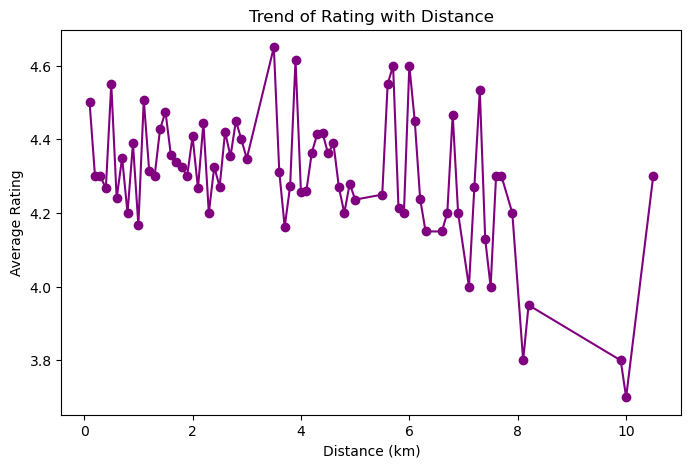

In [106]:
avg_rating = df.groupby("Distance_km")["Rating"].mean()

plt.figure(figsize=(8,5))

plt.plot(avg_rating.index, avg_rating.values, marker="o", color="purple")

plt.title("Trend of Rating with Distance")
plt.xlabel("Distance (km)")
plt.ylabel("Average Rating")

plt.show()

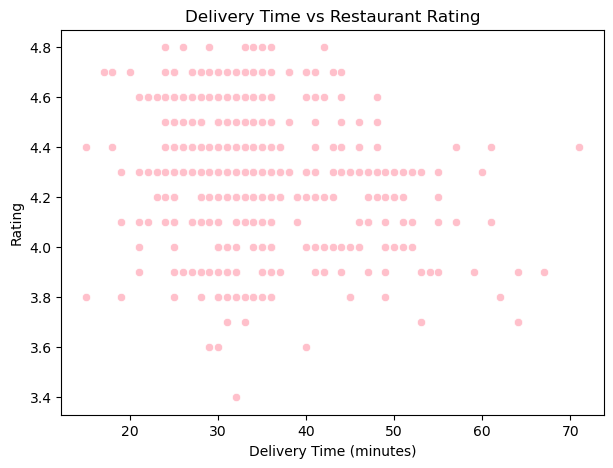

In [107]:
plt.figure(figsize=(7,5))

sns.scatterplot(x="Delivery_Time", y="Rating", data=df, color="pink")

plt.title("Delivery Time vs Restaurant Rating")
plt.xlabel("Delivery Time (minutes)")
plt.ylabel("Rating")

plt.show()

In [102]:
df["Delivery_Category"] = pd.cut(
    df["Delivery_Time"],
    bins=[0,25,35,60],
    labels=["Fast Delivery","Medium Delivery","Slow Delivery"]
)

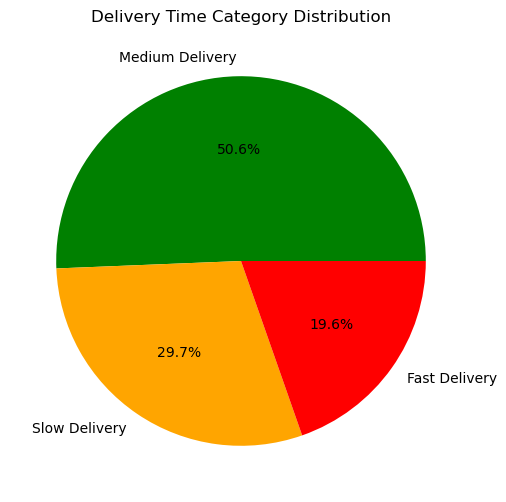

In [103]:
delivery_counts = df["Delivery_Category"].value_counts()

plt.figure(figsize=(6,6))

delivery_counts.plot(
    kind="pie",
    autopct="%1.1f%%",
    colors=["green","orange","red"]
)

plt.title("Delivery Time Category Distribution")
plt.ylabel("")

plt.show()

C:\Users\megha\AppData\Local\Temp\ipykernel_6644\3611057948.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


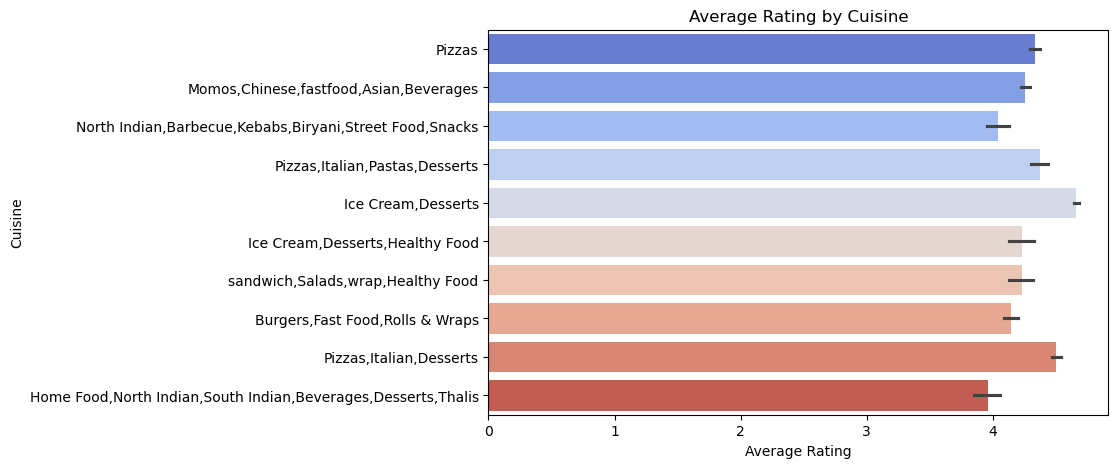

In [111]:
top_cuisine = df["Cuisine"].value_counts().head(10).index

plt.figure(figsize=(8,5))

sns.barplot(
    x="Rating",
    y="Cuisine",
    data=df[df["Cuisine"].isin(top_cuisine)],
    palette="coolwarm"
)

plt.title("Average Rating by Cuisine")
plt.xlabel("Average Rating")
plt.ylabel("Cuisine")

plt.show()

In [114]:
df.head()

,Restaurant,Rating,Cuisine,Delivery_Time,Location,Distance_km,Restaurant_ID,Delivery_Category
0,Pizza Hut,4.5,Pizzas,28,Kachiguda,1.6,408177,Medium Delivery
1,Wow! Momo,4.3,"Momos,Chinese,fastfood,Asian,Beverages",30,Himayath Nagar,2.7,360967,Medium Delivery
2,Barbeque Nation,3.9,"North Indian,Barbecue,Kebabs,Biryani,Street Fo...",42,ABIDS,1.6,603116,Slow Delivery
3,Domino's Pizza,4.6,"Pizzas,Italian,Pastas,Desserts",25,Kachiguda,3.0,28768,Fast Delivery
4,NIC Ice Creams,4.6,"Ice Cream,Desserts",21,Narayanguda,1.8,108986,Fast Delivery


C:\Users\megha\AppData\Local\Temp\ipykernel_6644\1301225405.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


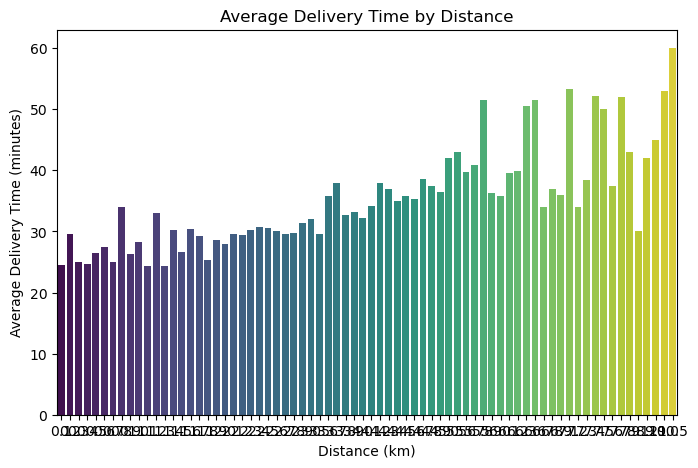

In [122]:
avg_time = df.groupby("Distance_km")["Delivery_Time"].mean()

plt.figure(figsize=(8,5))

sns.barplot(
    x=avg_time.index,
    y=avg_time.values,
    palette="viridis"
)

plt.title("Average Delivery Time by Distance")
plt.xlabel("Distance (km)")
plt.ylabel("Average Delivery Time (minutes)")

plt.show()

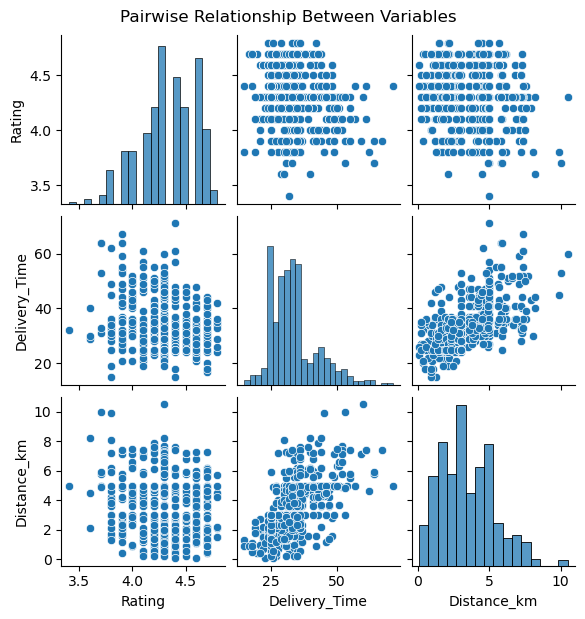

In [127]:
sns.pairplot(
    df[["Rating","Delivery_Time","Distance_km"]],
    diag_kind="hist",
    height=2
)

plt.suptitle("Pairwise Relationship Between Variables", y=1.02)

plt.show()

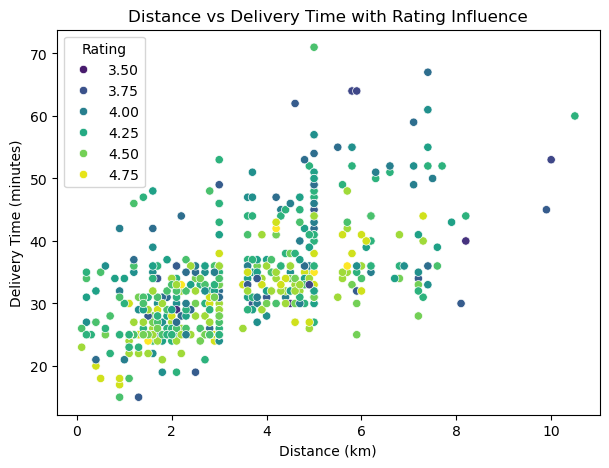

In [125]:
plt.figure(figsize=(7,5))

sns.scatterplot(
    x="Distance_km",
    y="Delivery_Time",
    hue="Rating",
    data=df,
    palette="viridis"
)

plt.title("Distance vs Delivery Time with Rating Influence")
plt.xlabel("Distance (km)")
plt.ylabel("Delivery Time (minutes)")

plt.show()